In [1]:
import matplotlib.pyplot
import pandas
from pathlib import Path

In [96]:
def parse_summary_log(file_path : str) -> pandas.DataFrame:
    columns = ['timestamp_ns', 'core', 'event', 'value', 'enabled', 'running']
    data_frame = pandas.read_csv(file_path, header=None, names=columns)
    data_frame['timestamp_ns'] = pandas.to_datetime(data_frame['timestamp_ns'], unit='ns')
    return data_frame.set_index('timestamp_ns').sort_index().fillna(1.0)

def parse_mutilate_agent_log(file_path : str) -> pandas.DataFrame:
    columns = ['timestamp_ns', 'lambda', 'delta_nops', 'qps_now', 'qps_now2']
    data_frame = pandas.read_csv(file_path, header=None, names=columns)
    data_frame['timestamp_ns'] = pandas.to_datetime(data_frame['timestamp_ns'], unit='ns')
    return data_frame.set_index("timestamp_ns").sort_index()

def parse_mutilate_leader_log(file_path : str) -> pandas.DataFrame:
    columns = ['timestamp_ns', 'read_p99']
    data_frame = pandas.read_csv(file_path, header=None, names=columns, skipfooter=12, engine="python")
    data_frame['timestamp_ns'] = pandas.to_datetime(data_frame['timestamp_ns'], unit='ns')
    return data_frame.set_index("timestamp_ns").sort_index()

def rate_per_core(data_frame : pandas.DataFrame, group_keys) -> pandas.Series:
    # `value` is a cumulative counter, so diff() gives a raw increase over
    # whatever the sampling interval happened to be (i.e. counts-per-sample,
    # not counts-per-second). Divide by the elapsed time between samples so
    # the result is a rate that's independent of the sampling interval.
    normalized = data_frame['value'] * data_frame['running'] / data_frame['enabled']
    diff = normalized.groupby(group_keys).diff()
    dt_seconds = data_frame.index.to_series().groupby(group_keys).diff().dt.total_seconds()
    return diff / dt_seconds

def plot_event(event : str) -> None:
    data_frame = parse_summary_log("results/summary.log")
    data_frame = data_frame[data_frame['event'] == event]

    rate = rate_per_core(data_frame, data_frame['core'])
    total = rate.groupby(data_frame.index).sum()

    figure, axis = matplotlib.pyplot.subplots(figsize=(20, 16))
    axis.plot(total)
    axis.set_xlabel("Time")
    axis.set_ylabel(f"{event} / s")
    figure.autofmt_xdate()
    #axis.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

def plot_mutilate() -> None:
    agent1_data_frame = parse_mutilate_agent_log("results/agent1.log")
    agent2_data_frame = parse_mutilate_agent_log("results/agent2.log")
    leader_data_frame = parse_mutilate_leader_log("results/leader.log")

    figure, axis = matplotlib.pyplot.subplots(figsize=(20, 16))
    axis.scatter(leader_data_frame.index, leader_data_frame['read_p99'])
    axis.plot(agent1_data_frame['qps_now'] / 1e1)
    axis.set_xlabel("Time")
    axis.set_ylabel("Read P99 latency")
    figure.autofmt_xdate()

def plot() -> None:
    probe_data_frame  = parse_summary_log("results/summary.log")

    agent1_data_frame = parse_mutilate_agent_log("results/agent1.log")
    agent2_data_frame = parse_mutilate_agent_log("results/agent2.log")
    leader_data_frame = parse_mutilate_leader_log("results/leader.log")

    group_keys = [probe_data_frame['event'], probe_data_frame['core']]
    rate = rate_per_core(probe_data_frame, group_keys)
    total = rate.groupby([probe_data_frame['event'], probe_data_frame.index]).sum().unstack('event')

    figure, left_axis = matplotlib.pyplot.subplots(figsize=(20, 16))

    left_axis.plot(total['cpu-cycles'] / 1e3, color="#feebe2", label="Kcpu-cycles/s")
    left_axis.plot(total['ref-cpu-cycles'] / 1e3, color="#fbb4b9", label="Kref-cycles/s")
    left_axis.plot(total['instructions'] / 1e3, color="#f768a1", label="Kinstructions/s")
    left_axis.plot(total['cache-misses'], color="#ae017e", label="Cache Misses/s")
    left_axis.legend()
    left_axis.set_xlabel("Time")

    right_color = '#d95f02'
    right_axis = left_axis.twinx()
    right_axis.scatter(leader_data_frame.index, leader_data_frame['read_p99'], marker='x', color=right_color, label="Read P99")
    right_axis.plot(agent1_data_frame['qps_now'] / 1e2, marker='o', color=right_color, label="Kqps")
    right_axis.legend()

    figure.autofmt_xdate()
    left_axis.grid(True, which='both', axis='both', linestyle='--', alpha=0.5)

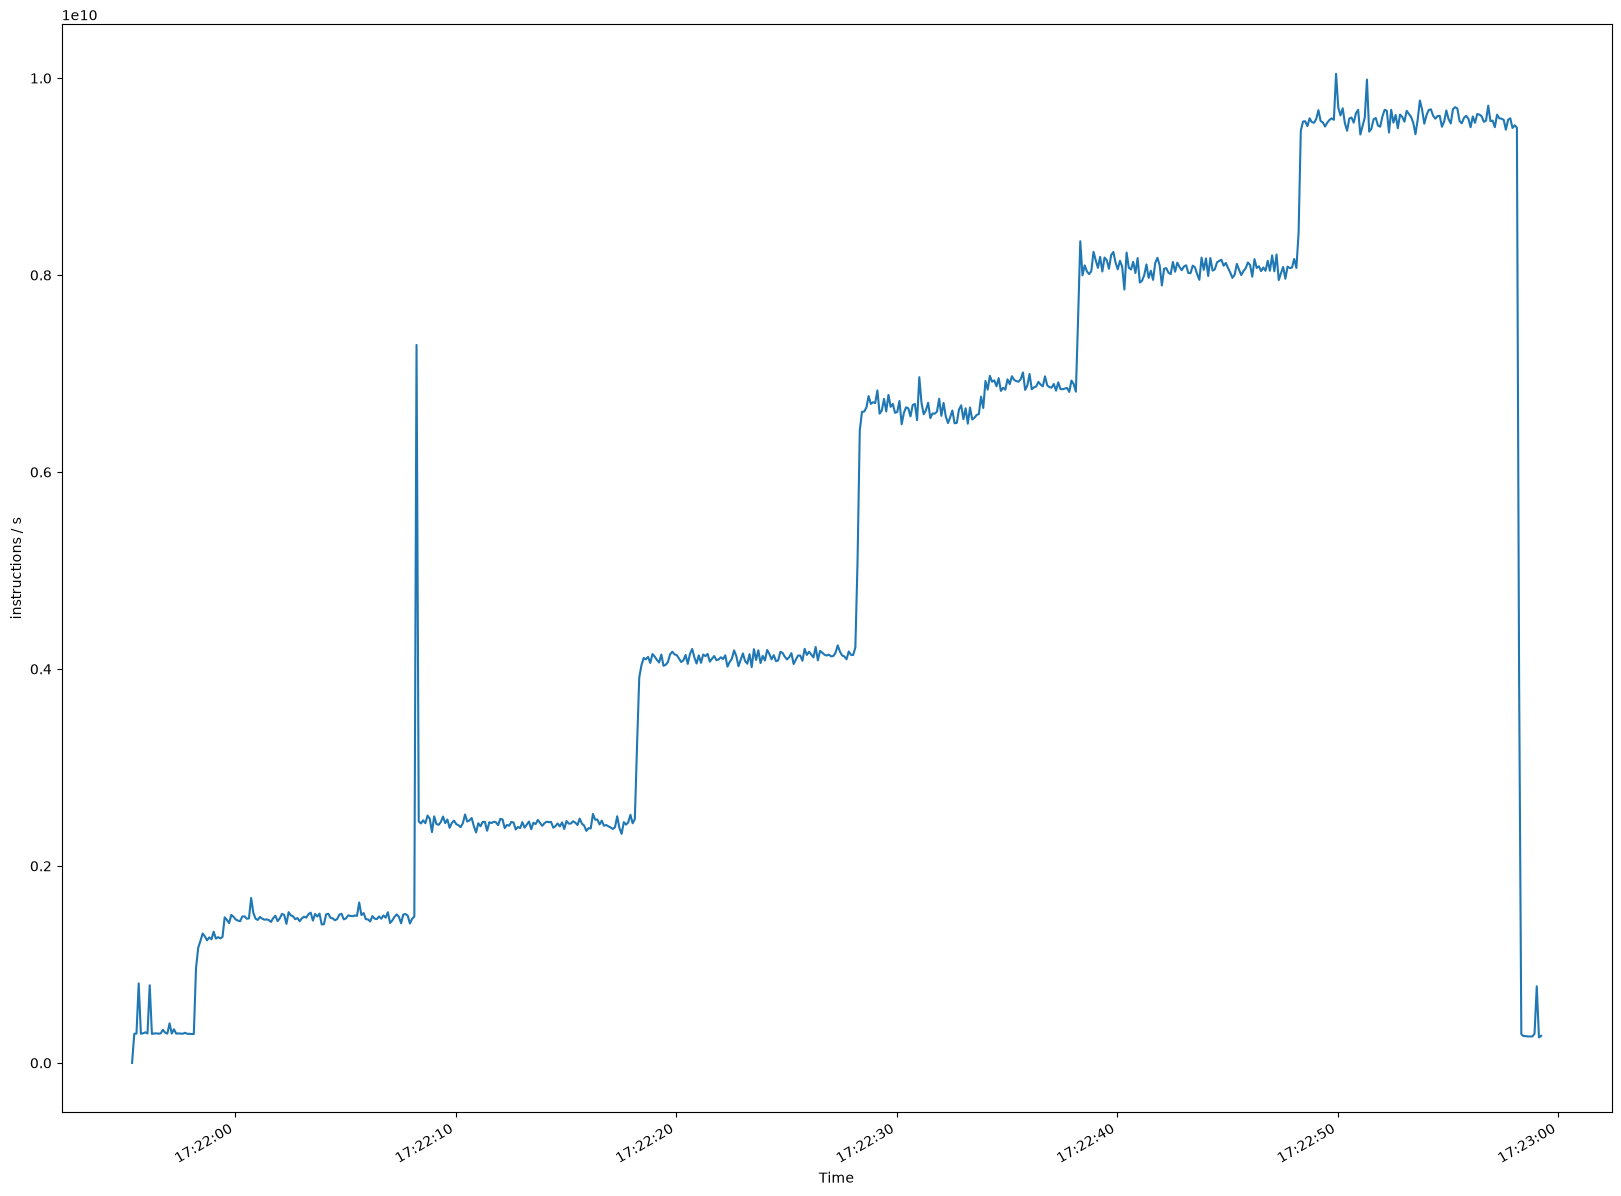

In [94]:
plot_event('instructions')

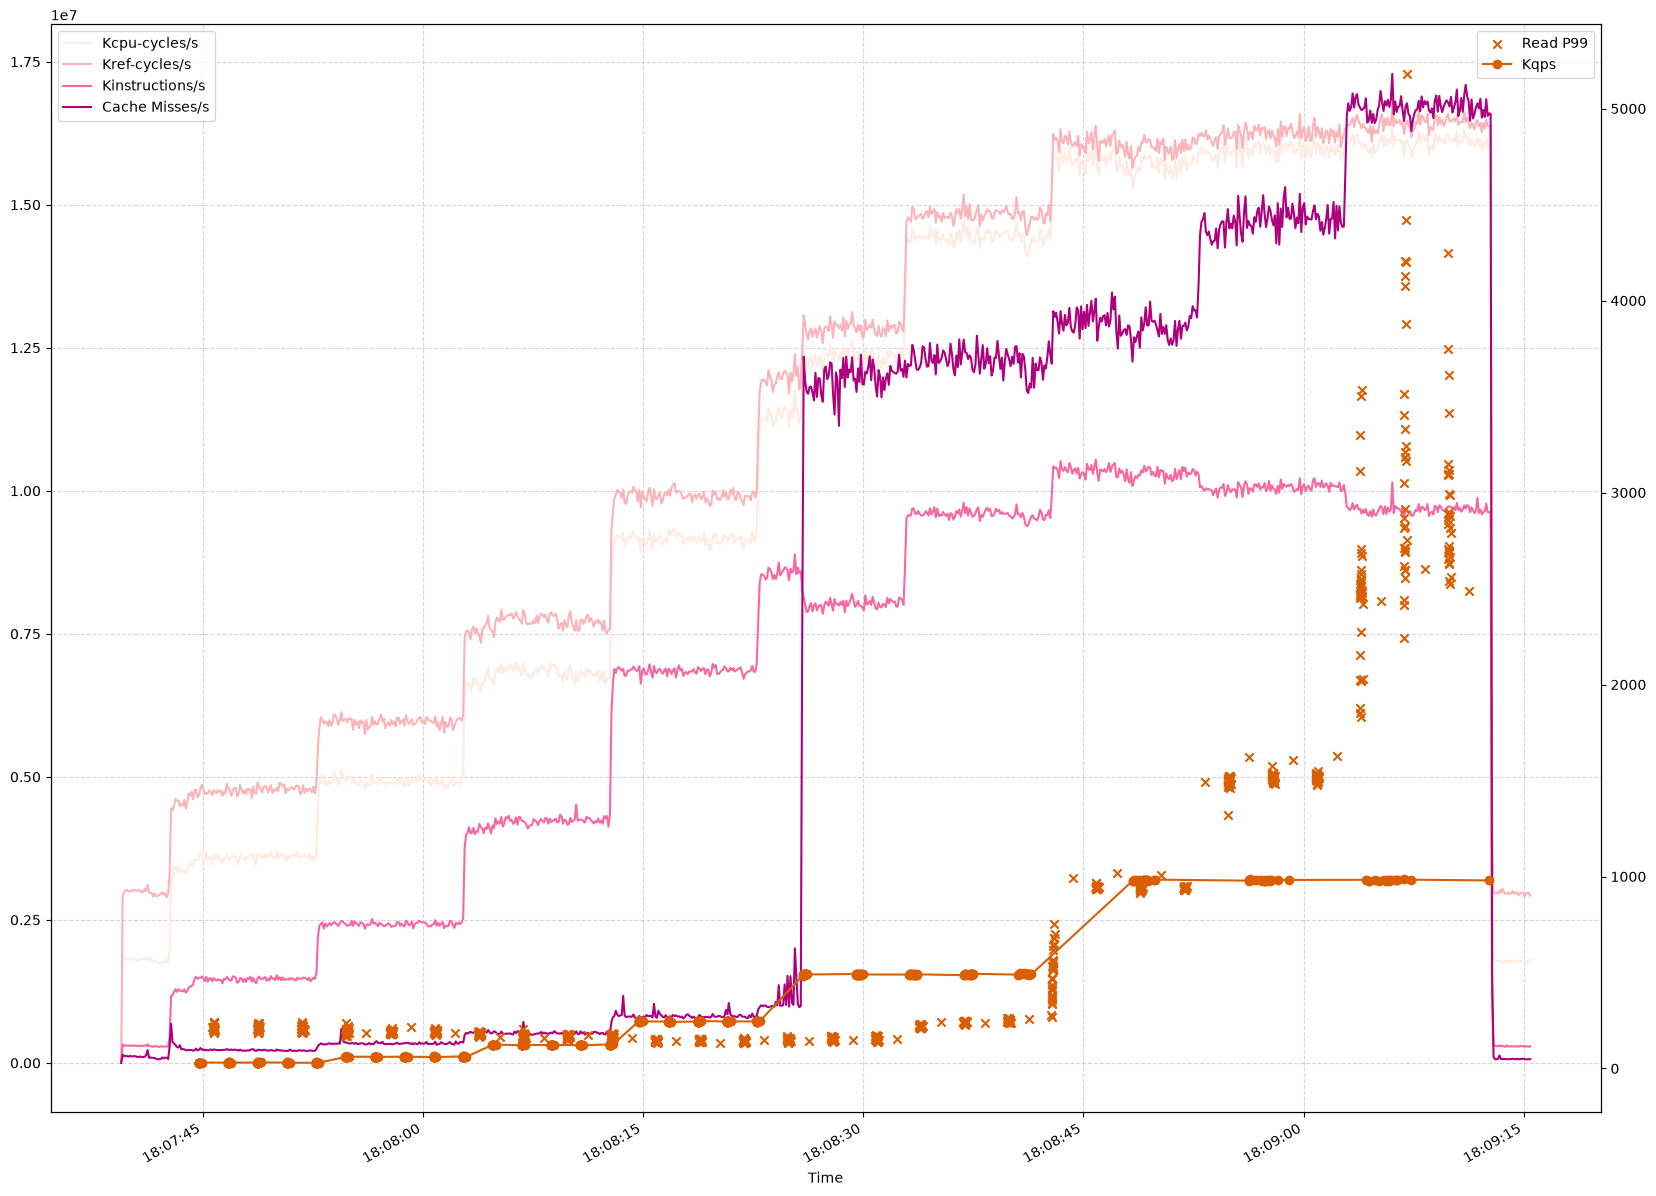

In [97]:
#parse_mutilate_agent_log("results/agent1.log")
#parse_mutilate_leader_log("results/leader.log")
#parse_summary_log("results/summary.log")
#plot_event("results/summary.log", 'tx_bytes')
#plot_mutilate()
plot()